<a href="https://colab.research.google.com/github/tarun3001/Python-Project-Social-Media-Addiction/blob/main/Mini_Project_Combating_Social_Media_Addiction_with_Data_Driven_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the CSV dataset


In [48]:
import numpy as np
import pandas as pd

from google.colab import files

uploaded = files.upload()

Saving Students Social Media Addiction (1).csv to Students Social Media Addiction (1) (1).csv


In [49]:
file_path = "Students Social Media Addiction (1).csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()


Dataset loaded successfully.
Rows: 705
Columns: 13


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


# Data Understanding



In [50]:
# Basic structure
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (705, 13)

Column names:
['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country', 'Avg_Daily_Usage_Hours', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Relationship_Status', 'Conflicts_Over_Social_Media', 'Addicted_Score']


In [51]:
print("\nData types and non-null counts:")
df.info()


Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                7

In [52]:
print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,705.0,NaN,NaN,NaN,353.0,203.660256,1.0,177.0,353.0,529.0,705.0
Age,705.0,NaN,NaN,NaN,20.659574,1.399217,18.0,19.0,21.0,22.0,24.0
Gender,705,2,Female,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic_Level,705,3,Undergraduate,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,705,110,India,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg_Daily_Usage_Hours,705.0,NaN,NaN,NaN,4.918723,1.257395,1.5,4.1,4.8,5.8,8.5
Most_Used_Platform,705,12,Instagram,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Affects_Academic_Performance,705,2,Yes,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours_Per_Night,705.0,NaN,NaN,NaN,6.868936,1.126848,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,705.0,NaN,NaN,NaN,6.22695,1.105055,4.0,5.0,6.0,7.0,9.0


In [53]:
print("\nUnique values in categorical columns:")
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())



Unique values in categorical columns:

Gender:
Gender
Female    353
Male      352
Name: count, dtype: int64

Academic_Level:
Academic_Level
Undergraduate    353
Graduate         325
High School       27
Name: count, dtype: int64

Country:
Country
India          53
USA            40
Canada         34
France         27
Mexico         27
               ..
Oman            1
Afghanistan     1
Syria           1
Yemen           1
Bhutan          1
Name: count, Length: 110, dtype: int64

Most_Used_Platform:
Most_Used_Platform
Instagram    249
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      21
WeChat        15
Snapchat      13
VKontakte     12
LINE          12
KakaoTalk     12
YouTube       10
Name: count, dtype: int64

Affects_Academic_Performance:
Affects_Academic_Performance
Yes    453
No     252
Name: count, dtype: int64

Relationship_Status:
Relationship_Status
Single             384
In Relationship    289
Complicated         32
Name: count, dtype: int64


# Data Cleaning and visualisation



In [54]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing values by column:")
display(missing_values.to_frame("Missing_Count"))

Missing values by column:


,Missing_Count
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [55]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [56]:
# Convert numeric columns explicitly to numeric types.
# errors='raise' makes unexpected non-numeric values visible instead of silently hiding them.
numeric_cols = [
    "Student_ID", "Age", "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night", "Mental_Health_Score",
    "Conflicts_Over_Social_Media", "Addicted_Score"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="raise")

In [57]:
# Convert categorical columns to pandas category dtype.
categorical_cols = [
    "Gender", "Academic_Level", "Country", "Most_Used_Platform",
    "Affects_Academic_Performance", "Relationship_Status"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print("\nCleaning complete.")
print("Remaining missing values:", int(df.isnull().sum().sum()))
print("Remaining duplicate rows:", int(df.duplicated().sum()))


Cleaning complete.
Remaining missing values: 0
Remaining duplicate rows: 0


# Feature Engineering


In [58]:
# Function 1: classify risk from daily social-media usage
def classify_risk(usage_hours):
    if usage_hours < 3:
        return "Low"
    elif usage_hours < 6:
        return "Medium"
    else:
        return "High"

In [59]:
# Function 2: classify age groups
def classify_age(age):
    if age <= 19:
        return "18-19"
    elif age <= 21:
        return "20-21"
    else:
        return "22-24"

In [60]:
# Function 3: classify sleep pattern
def classify_sleep(sleep_hours):
    if sleep_hours < 7:
        return "Below 7 hours"
    else:
        return "7+ hours"

In [61]:
# Function 4: suggest a digital-detox strategy
def detox_strategy(row):
    usage = row["Avg_Daily_Usage_Hours"]
    sleep = row["Sleep_Hours_Per_Night"]
    academic_impact = row["Affects_Academic_Performance"]
    conflicts = row["Conflicts_Over_Social_Media"]

    if usage >= 6 and sleep < 7 and academic_impact == "Yes":
        return "High priority: app limits, phone-free bedtime, and study-time blocks."
    elif usage >= 6 or conflicts >= 4:
        return "High priority: scheduled social-media breaks and daily app limits."
    elif sleep < 7 or academic_impact == "Yes":
        return "Moderate: protect sleep/study time and schedule social-media-free periods."
    else:
        return "Maintain healthy limits and regular offline activities."

In [62]:
# Create engineered features
df["Age_Group"] = df["Age"].apply(classify_age)
df["Usage_Risk_Level"] = df["Avg_Daily_Usage_Hours"].apply(classify_risk)
df["Sleep_Category"] = df["Sleep_Hours_Per_Night"].apply(classify_sleep)
df["Academic_Impact_Flag"] = df["Affects_Academic_Performance"].map({"Yes": 1, "No": 0})
df["High_Conflict_Flag"] = (df["Conflicts_Over_Social_Media"] >= 4).astype(int)
df["Digital_Detox_Strategy"] = df.apply(detox_strategy, axis=1)

print("Feature engineering completed.")
display(df[[
    "Age", "Age_Group",
    "Avg_Daily_Usage_Hours", "Usage_Risk_Level",
    "Sleep_Hours_Per_Night", "Sleep_Category",
    "Academic_Impact_Flag", "High_Conflict_Flag",
    "Digital_Detox_Strategy"
]].head(10))

Feature engineering completed.


,Age,Age_Group,Avg_Daily_Usage_Hours,Usage_Risk_Level,Sleep_Hours_Per_Night,Sleep_Category,Academic_Impact_Flag,High_Conflict_Flag,Digital_Detox_Strategy
0,19,18-19,5.2,Medium,6.5,Below 7 hours,1,0,Moderate: protect sleep/study time and schedul...
1,22,22-24,2.1,Low,7.5,7+ hours,0,0,Maintain healthy limits and regular offline ac...
2,20,20-21,6.0,High,5.0,Below 7 hours,1,1,"High priority: app limits, phone-free bedtime,..."
3,18,18-19,3.0,Medium,7.0,7+ hours,0,0,Maintain healthy limits and regular offline ac...
4,21,20-21,4.5,Medium,6.0,Below 7 hours,1,0,Moderate: protect sleep/study time and schedul...
5,19,18-19,7.2,High,4.5,Below 7 hours,1,1,"High priority: app limits, phone-free bedtime,..."
6,23,22-24,1.5,Low,8.0,7+ hours,0,0,Maintain healthy limits and regular offline ac...
7,20,20-21,5.8,Medium,6.0,Below 7 hours,1,0,Moderate: protect sleep/study time and schedul...
8,18,18-19,4.0,Medium,6.5,Below 7 hours,0,0,Moderate: protect sleep/study time and schedul...
9,21,20-21,3.3,Medium,7.0,7+ hours,0,0,Maintain healthy limits and regular offline ac...


# Feature Engineering Distrbution



In [63]:
print("Usage risk distribution:")
display(df["Usage_Risk_Level"].value_counts().reindex(["Low", "Medium", "High"]).to_frame("Students"))

print("\nAge-group distribution:")
display(df["Age_Group"].value_counts().reindex(["18-19", "20-21", "22-24"]).to_frame("Students"))

print("\nSleep categories:")
display(df["Sleep_Category"].value_counts().to_frame("Students"))

Usage risk distribution:


,Students
Usage_Risk_Level,
Low,43
Medium,512
High,150



Age-group distribution:


,Students
Age_Group,
18-19,177
20-21,321
22-24,207



Sleep categories:


,Students
Sleep_Category,
Below 7 hours,359
7+ hours,346


Exploratory Distribution Analysis (EDA)

In [64]:
numeric_analysis_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score"
]

correlation_with_addiction = (
    df[numeric_analysis_cols]
    .corr()["Addicted_Score"]
    .sort_values(ascending=False)
)

display(correlation_with_addiction.to_frame("Correlation_with_Addicted_Score"))

,Correlation_with_Addicted_Score
Addicted_Score,1.000000
Conflicts_Over_Social_Media,0.933586
Avg_Daily_Usage_Hours,0.832000
Age,-0.166396
Sleep_Hours_Per_Night,-0.764858
Mental_Health_Score,-0.945051


# Groupby and Aggregation

Average addiction level by gender


In [65]:
gender_summary = (
    df.groupby("Gender", observed=True)
      .agg(
          Students=("Student_ID", "count"),
          Avg_Addicted_Score=("Addicted_Score", "mean"),
          Avg_Usage_Hours=("Avg_Daily_Usage_Hours", "mean"),
          Avg_Sleep_Hours=("Sleep_Hours_Per_Night", "mean")
      )
      .sort_values("Avg_Addicted_Score", ascending=False)
      .round(2)
)

display(gender_summary)

,Students,Avg_Addicted_Score,Avg_Usage_Hours,Avg_Sleep_Hours
Gender,,,,
Female,353,6.52,5.01,6.82
Male,352,6.36,4.83,6.92


Average addiction level by age group


In [66]:
age_group_summary = (
    df.groupby("Age_Group", observed=True)
      .agg(
          Students=("Student_ID", "count"),
          Avg_Addicted_Score=("Addicted_Score", "mean"),
          Avg_Usage_Hours=("Avg_Daily_Usage_Hours", "mean")
      )
      .reindex(["18-19", "20-21", "22-24"])
      .round(2)
)

display(age_group_summary)

,Students,Avg_Addicted_Score,Avg_Usage_Hours
Age_Group,,,
18-19,177,6.74,5.14
20-21,321,6.53,4.94
22-24,207,6.03,4.70


Average addiction level by education level

In [67]:
education_summary = (
    df.groupby("Academic_Level", observed=True)
      .agg(
          Students=("Student_ID", "count"),
          Avg_Addicted_Score=("Addicted_Score", "mean"),
          Avg_Usage_Hours=("Avg_Daily_Usage_Hours", "mean"),
          Avg_Sleep_Hours=("Sleep_Hours_Per_Night", "mean")
      )
      .sort_values("Avg_Addicted_Score", ascending=False)
      .round(2)
)

display(education_summary)

,Students,Avg_Addicted_Score,Avg_Usage_Hours,Avg_Sleep_Hours
Academic_Level,,,,
High School,27,8.04,5.54,5.46
Undergraduate,353,6.49,5.00,6.83
Graduate,325,6.24,4.78,7.03


Bar Chart: Addiction by Gender


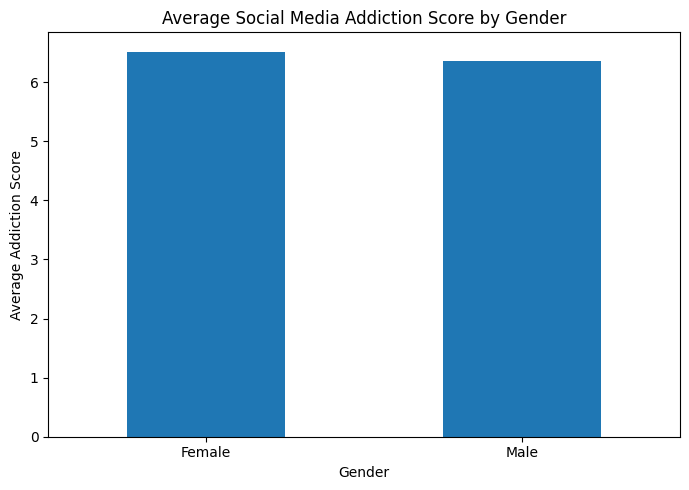

In [68]:
gender_means = df.groupby("Gender", observed=True)["Addicted_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
gender_means.plot(kind="bar")
plt.title("Average Social Media Addiction Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Addiction Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Pie Chart: Usage Risk Distribution

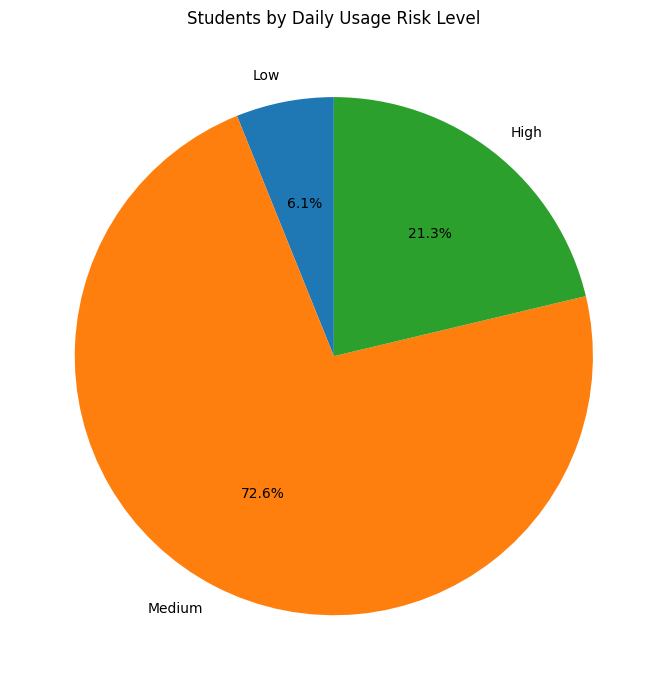

In [69]:
risk_counts = df["Usage_Risk_Level"].value_counts().reindex(["Low", "Medium", "High"])

plt.figure(figsize=(7, 7))
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Students by Daily Usage Risk Level")
plt.tight_layout()
plt.show()

Line Chart: Addiction by Age

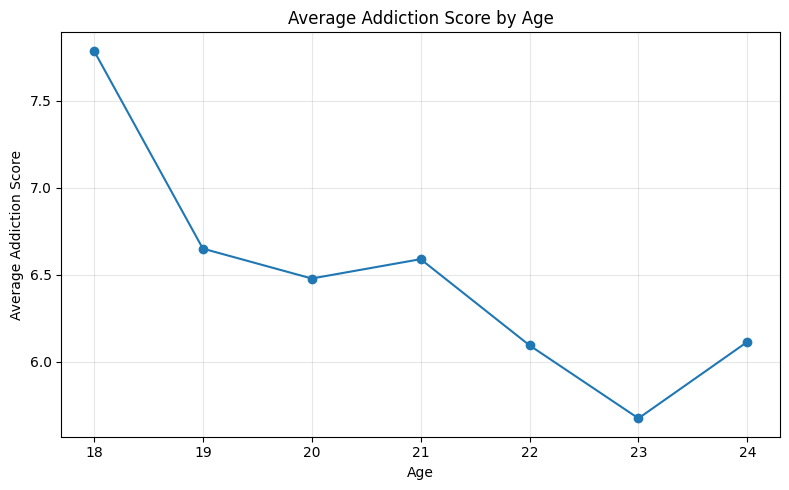

In [70]:
age_trend = (
    df.groupby("Age", observed=True)["Addicted_Score"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(8, 5))
plt.plot(age_trend.index, age_trend.values, marker="o")
plt.title("Average Addiction Score by Age")
plt.xlabel("Age")
plt.ylabel("Average Addiction Score")
plt.xticks(age_trend.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Correaltion Heatmap

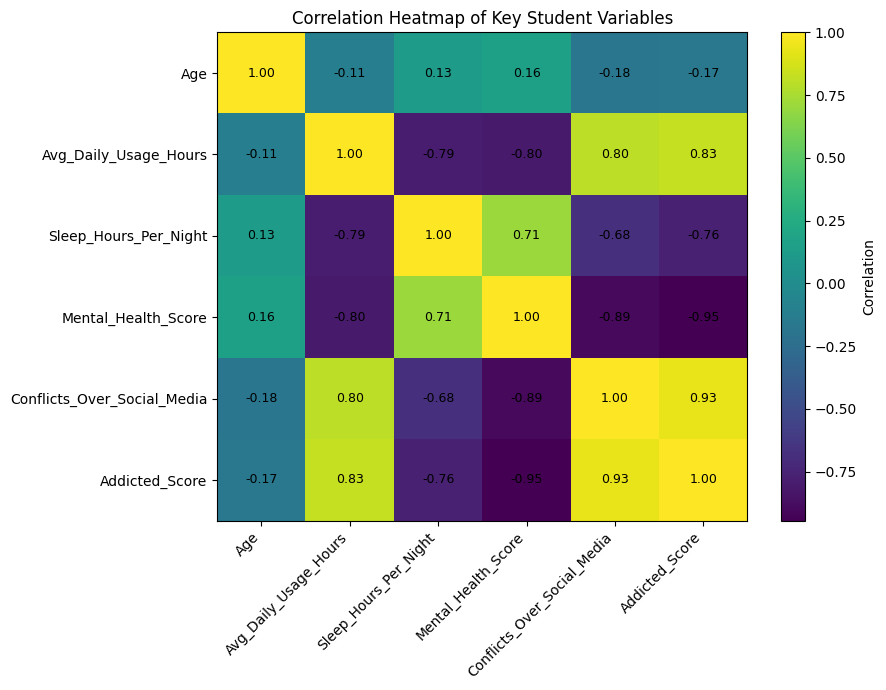

In [71]:
corr_matrix = df[numeric_analysis_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values to every cell
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9)

ax.set_title("Correlation Heatmap of Key Student Variables")
fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

Scatter Plot: Daily Usage vs Addiction

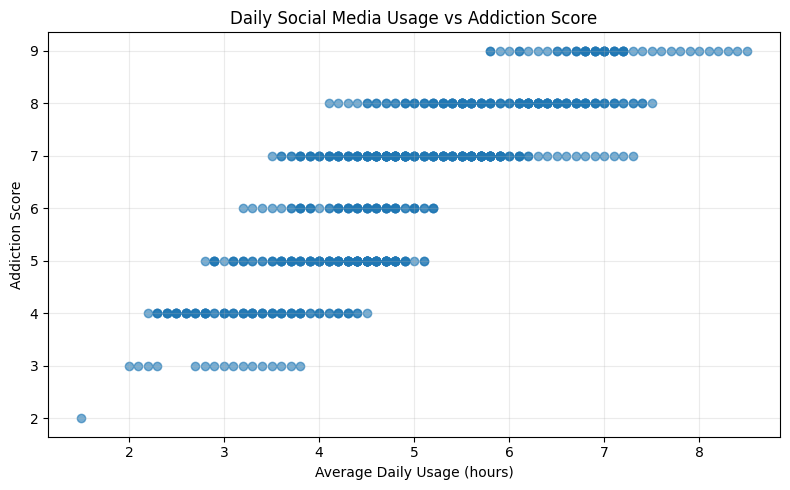

In [72]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Avg_Daily_Usage_Hours"], df["Addicted_Score"], alpha=0.6)
plt.title("Daily Social Media Usage vs Addiction Score")
plt.xlabel("Average Daily Usage (hours)")
plt.ylabel("Addiction Score")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Additon EDA: Sleep, Academic Performance and Social Conflicts

In [73]:
# Compare addiction for students whose academic performance is reported as affected vs not affected
academic_impact_summary = (
    df.groupby("Affects_Academic_Performance", observed=True)
      .agg(
          Students=("Student_ID", "count"),
          Avg_Addicted_Score=("Addicted_Score", "mean"),
          Avg_Usage_Hours=("Avg_Daily_Usage_Hours", "mean"),
          Avg_Sleep_Hours=("Sleep_Hours_Per_Night", "mean")
      )
      .round(2)
)

display(academic_impact_summary)

,Students,Avg_Addicted_Score,Avg_Usage_Hours,Avg_Sleep_Hours
Affects_Academic_Performance,,,,
No,252,4.60,3.80,7.81
Yes,453,7.46,5.54,6.34


In [74]:
# Addiction by sleep category
sleep_summary = (
    df.groupby("Sleep_Category", observed=True)
      .agg(
          Students=("Student_ID", "count"),
          Avg_Addicted_Score=("Addicted_Score", "mean"),
          Avg_Usage_Hours=("Avg_Daily_Usage_Hours", "mean")
      )
      .round(2)
)

display(sleep_summary)

,Students,Avg_Addicted_Score,Avg_Usage_Hours
Sleep_Category,,,
7+ hours,346,5.24,3.99
Below 7 hours,359,7.59,5.81


In [75]:
# Addiction by conflict level
conflict_summary = (
    df.groupby("Conflicts_Over_Social_Media", observed=True)["Addicted_Score"]
      .agg(["count", "mean"])
      .rename(columns={"count": "Students", "mean": "Avg_Addicted_Score"})
      .round(2)
)

display(conflict_summary)

,Students,Avg_Addicted_Score
Conflicts_Over_Social_Media,,
0,4,2.75
1,47,3.85
2,204,4.85
3,261,6.86
4,174,8.22
5,15,9.00


# Platform Level Analysis

In [76]:
platform_summary = (
    df.groupby("Most_Used_Platform", observed=True)
      .agg(
          Students=("Student_ID", "count"),
          Avg_Addicted_Score=("Addicted_Score", "mean"),
          Avg_Usage_Hours=("Avg_Daily_Usage_Hours", "mean")
      )
      .sort_values("Avg_Addicted_Score", ascending=False)
      .round(2)
)

display(platform_summary)

,Students,Avg_Addicted_Score,Avg_Usage_Hours
Most_Used_Platform,,,
WhatsApp,54,7.46,6.48
Snapchat,13,7.46,5.09
TikTok,154,7.43,5.35
Instagram,249,6.55,4.87
YouTube,10,6.10,4.08
WeChat,15,6.07,4.96
KakaoTalk,12,6.00,4.73
Facebook,123,5.67,4.51
Twitter,30,5.50,4.87


# Personalized Digital- Detox Recomendations

In [77]:
# Demonstrate the custom functions on selected students
demo_cols = [
    "Student_ID", "Avg_Daily_Usage_Hours", "Usage_Risk_Level",
    "Sleep_Hours_Per_Night", "Affects_Academic_Performance",
    "Conflicts_Over_Social_Media", "Digital_Detox_Strategy"
]

display(df[demo_cols].head(10))

# Count how many students receive each strategy
strategy_counts = df["Digital_Detox_Strategy"].value_counts()
display(strategy_counts.to_frame("Students"))

,Student_ID,Avg_Daily_Usage_Hours,Usage_Risk_Level,Sleep_Hours_Per_Night,Affects_Academic_Performance,Conflicts_Over_Social_Media,Digital_Detox_Strategy
0,1,5.2,Medium,6.5,Yes,3,Moderate: protect sleep/study time and schedul...
1,2,2.1,Low,7.5,No,0,Maintain healthy limits and regular offline ac...
2,3,6.0,High,5.0,Yes,4,"High priority: app limits, phone-free bedtime,..."
3,4,3.0,Medium,7.0,No,1,Maintain healthy limits and regular offline ac...
4,5,4.5,Medium,6.0,Yes,2,Moderate: protect sleep/study time and schedul...
5,6,7.2,High,4.5,Yes,5,"High priority: app limits, phone-free bedtime,..."
6,7,1.5,Low,8.0,No,0,Maintain healthy limits and regular offline ac...
7,8,5.8,Medium,6.0,Yes,2,Moderate: protect sleep/study time and schedul...
8,9,4.0,Medium,6.5,No,1,Moderate: protect sleep/study time and schedul...
9,10,3.3,Medium,7.0,No,1,Maintain healthy limits and regular offline ac...


,Students
Digital_Detox_Strategy,
Moderate: protect sleep/study time and schedule social-media-free periods.,262
Maintain healthy limits and regular offline activities.,235
"High priority: app limits, phone-free bedtime, and study-time blocks.",149
High priority: scheduled social-media breaks and daily app limits.,59


# Example

In [78]:
# A simple loop that prints a monitoring message for each risk level.
risk_order = ["Low", "Medium", "High"]

for risk in risk_order:
    count = (df["Usage_Risk_Level"] == risk).sum()

    if risk == "Low":
        action = "Maintain healthy habits."
    elif risk == "Medium":
        action = "Introduce regular screen-free breaks."
    else:
        action = "Prioritize app limits and structured digital-detox periods."

    print(f"{risk} risk: {count} students -> {action}")

Low risk: 43 students -> Maintain healthy habits.
Medium risk: 512 students -> Introduce regular screen-free breaks.
High risk: 150 students -> Prioritize app limits and structured digital-detox periods.


# Key Findings

In [79]:
# Automatically calculate a few headline statistics for the report
headline_stats = {
    "Students": len(df),
    "Average daily usage (hours)": df["Avg_Daily_Usage_Hours"].mean(),
    "Average addiction score": df["Addicted_Score"].mean(),
    "High usage-risk students": (df["Usage_Risk_Level"] == "High").sum(),
    "Academic impact = Yes": (df["Affects_Academic_Performance"] == "Yes").sum(),
    "Below 7 hours sleep": (df["Sleep_Hours_Per_Night"] < 7).sum(),
    "High conflict (4-5)": (df["Conflicts_Over_Social_Media"] >= 4).sum()
}

for key, value in headline_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

Students: 705
Average daily usage (hours): 4.92
Average addiction score: 6.44
High usage-risk students: 150
Academic impact = Yes: 453
Below 7 hours sleep: 359
High conflict (4-5): 189


# Main Insights

- Average daily social-media use is about 4.92 hours, and the average addiction score is roughly 6.44/10.

- The majority of pupils fall into the medium-risk category, although 150 are categorized as high usage risk (6+ hours per day).

- Every day has a strong good connotation.

- Conflicts on social media are significantly more positively correlated with the addiction score.

- There are significant negative correlations between the addiction score and sleep duration and mental health score.

- Compared to students who have no academic influence, those who indicate academic impact have significantly greater average levels of addiction and usage.

# Actions for Digital-Detox Program

1. Offer app timers, planned social media-free periods, and weekly self-monitoring to kids who use them frequently.

2. Protect sleep: Encourage a phone-free period before bedtime, especially for students sleeping under 7 hours.

3. Set up study periods with social media notifications turned off to safeguard academic time.

4. Resolve disputes: When social media is causing interpersonal issues, provide communication and boundary-setting advice.

# 10 Line Story Summary

1. The average student in this dataset spends about five hours a day on social media, demonstrating how deeply ingrained social media is in student life.

2. While 150 pupils attain the high-risk level of six or more hours per day, the majority of students fall into the medium usage-risk category.

3. Higher daily usage is highly associated with higher addiction scores.

4. Interpersonal issues are a crucial warning indicator because social media fights have an even larger positive correlation with addiction.

5. Compared to students who indicate no academic influence, those who express academic impact have much higher addiction scores and everyday usage.

6. The significance of maintaining bedtime routines is shown by the correlation between lower sleep duration and higher addiction ratings.

7. Additionally, mental health ratings go in the opposite direction of addiction scores, indicating that digital health monitoring should take wellness into account.

8. Younger kids are younger students, higher, and these findings, and these findings, and these students, and these group scores.

9. Sleep program program program program program program is a practical study study program, conflict, conflict program.

10. The strong digital strategy is not to use students's, but not to help students's, but not to use, but to help, but to use data, but to aid.

# Conclusion

- The analysis shows how student-level data can be transformed into useful information about mental health. Daily usage, social media conflicts, sleep, mental health scores, and academic influence are the most obvious signs of addiction. A data-driven intervention should therefore focus on these measurable behaviors and outcomes, regularly evaluate whether treatments work, and avoid considering correlation as causation.